# MIDTERM Financial Derivatives

> Participants: Bob Hunold, Elliot Jonsson, Melody Cohen, Augstin Lemarquand, Tobias Rungg, Constantin Schmidt-Chiari, Kristina Mihaylova, Tim Hirndorf

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import scienceplots
from scipy.linalg import solve_banded
plt.style.use(['science','notebook'])

In [63]:
# Given Data 

S_0 = 100 # Spot price at t=0
K = 100 # Strike price 
sigma = 0.2 # Volatility of underlying 
rf = 0.0394 # Risk-Free rate (taken form the 1m US Treasury )
T = 1 # Time to expiry (in years)

## 1. Black-Scholes

Price of a European call option:

$$
C = S_0\,N(d_1) - K e^{-rT} N(d_2)
$$

Price of a European put option:

$$
P = K e^{-rT} N(-d_2) - S_0\,N(-d_1)
$$

$$
d_1 = \frac{\ln\left(\frac{S_0}{K}\right) + \left(r + \frac{\sigma^2}{2}\right)T}{\sigma\sqrt{T}}
$$

$$
d_2 = d_1 - \sigma\sqrt{T}
$$

In [64]:
def BlackScholes(S_0, K, sigma, rf, T, option_type="C"):

    d1 = (np.log(S_0 / K) + (rf + (sigma**2)/2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type=="C":
        price = S_0 * norm.cdf(d1) - K*np.exp(-rf * T)*norm.cdf(d2)
    elif option_type=="P":
        price = K * np.exp(-rf*T) * norm.cdf(-d2) - S_0 * norm.cdf(-d1)
    else:
        raise ValueError("Option mus of of type Call (C) or Put (P)")

    return price

In [65]:
Call = BlackScholes(S_0, K, sigma, rf, T)
Put = BlackScholes(S_0, K, sigma, rf, T, option_type="P")

print(f"Call: {Call}, Put: {Put}")

Call: 9.893959068455047, Put: 6.030567647705773


## 2. Monte-Carlo Simulation

In [66]:
def MonteCarlo(S_0, K, sigma, rf, T, M, option_type="C", seed=None):
    """
    Prices a European option by Monte-Carlo simulation.
    M = number of simulated scenarios (paths) for the stock price.
    Returns the estimated price and its standard error.
    """

    # Random number generator. Fixing the seed makes the results reproducible:
    # running the cell twice gives exactly the same "random" numbers.
    rng = np.random.default_rng(seed)

    # Step 1: draw M independent standard normal shocks Z ~ N(0, 1).
    # Each Z represents one possible "state of the world" at expiry.
    Z = rng.standard_normal(M)

    # Step 2: turn each shock into a stock price at expiry using the GBM solution
    # - drift is the risk-free rate rf 
    S_T = S_0 * np.exp((rf - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

    # Step 3: payoff of the option in each scenario (vectorised over all M scenarios)
    if option_type == "C":
        payoffs = np.maximum(S_T - K, 0)   # call: max(S_T - K, 0)
    elif option_type == "P":
        payoffs = np.maximum(K - S_T, 0)   # put:  max(K - S_T, 0)

    # Step 4: discount every payoff back to today (t = 0)
    discounted_payoffs = np.exp(-rf * T) * payoffs

    # Step 5: the price is the average of the discounted payoffs.
    # By the law of large numbers this converges to the true expectation as M grows.
    price = discounted_payoffs.mean()

    # Step 6: standard error = how uncertain our estimate is.
    # SE = sample std / sqrt(M)  ->  to halve the error you need 4x as many paths.
    std_error = discounted_payoffs.std(ddof=1) / np.sqrt(M)

    return price, std_error



In [67]:
# Run the simulation with the given data
M = 100000000
mc_call, mc_call_se = MonteCarlo(S_0, K, sigma, rf, T, M, option_type="C", seed=42)
mc_put, mc_put_se = MonteCarlo(S_0, K, sigma, rf, T, M, option_type="P", seed=42)

# 95% confidence interval: estimate +/- 1.96 standard errors
print(f"MC-Call: {mc_call}; MC-Put: {mc_put}")
print(f"Standard error Call: {mc_call_se}; Standard error Put: {mc_put_se}")
print(f"95% confidence interval: Call:[{mc_call - 1.96*mc_call_se}, {mc_call + 1.96*mc_call_se}], Put: [{mc_put - 1.96*mc_put_se}, {mc_put + 1.96*mc_put_se}]")

MC-Call: 9.895949353626165; MC-Put: 6.029139051008871
Standard error Call: 0.0014403289659938468; Standard error Put: 0.000902103394467168
95% confidence interval: Call:[9.893126308852816, 9.898772398399514], Put: [6.027370928355715, 6.030907173662026]


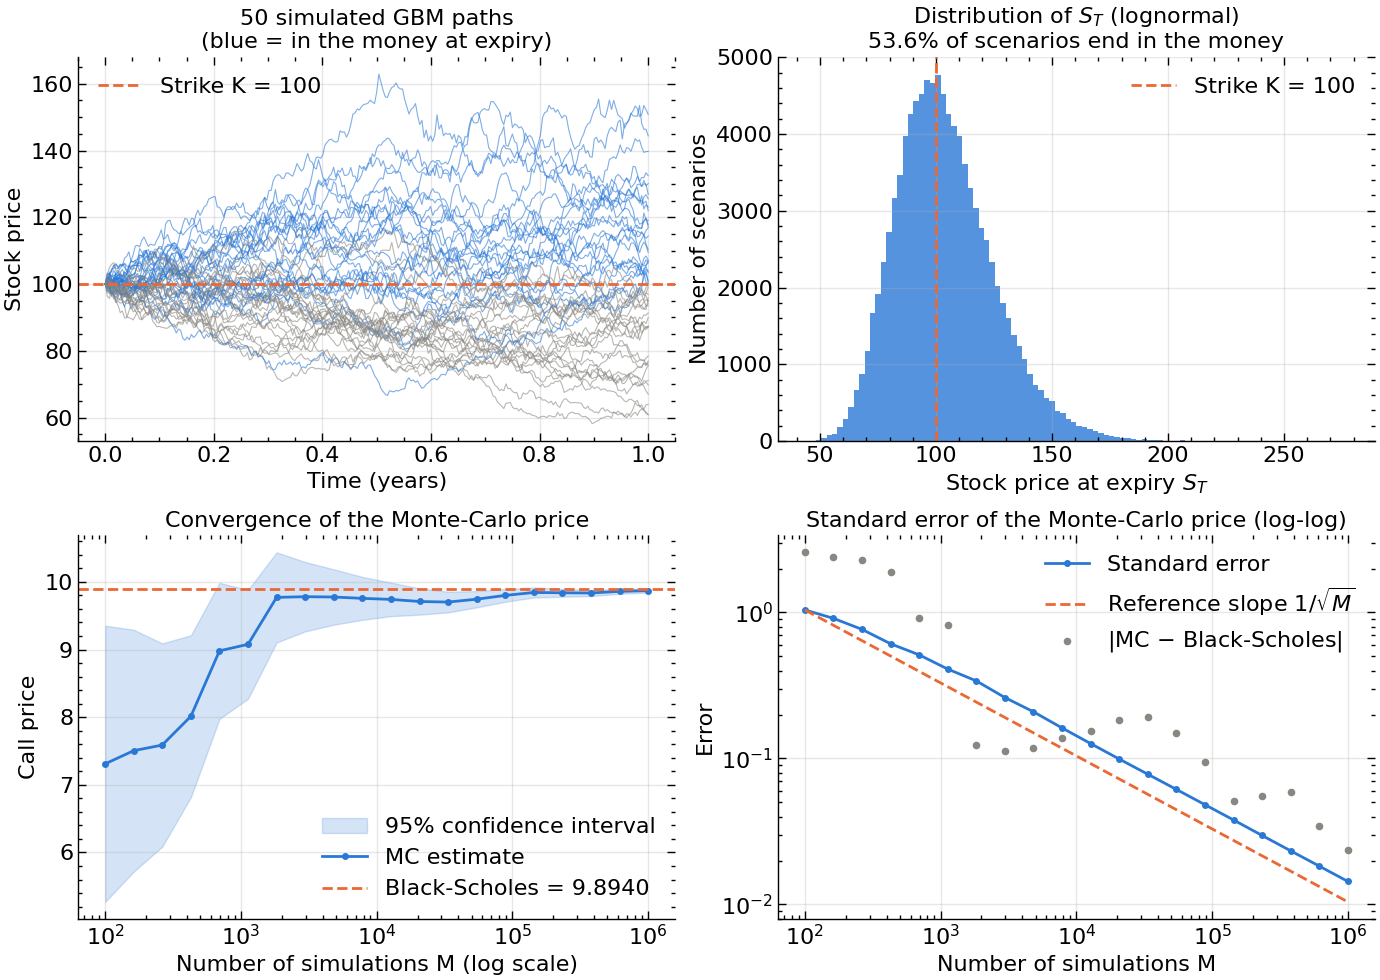

In [68]:
# Visualising the Monte-Carlo simulation

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#898781"

bs_call = BlackScholes(S_0, K, sigma, rf, T)   # reference price

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()   # so we can use axes[0] ... axes[3]


# Plot 1: simulated stock price paths
# For the picture we simulate whole paths (252 trading days) instead of jumping
# straight to S_T. Each step applies the same GBM formula over a small dt.
n_paths, n_steps = 50, 252
dt = T / n_steps
Z = rng.standard_normal((n_paths, n_steps))
log_returns = (rf - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
# cumulative sum of log returns = log(S_t / S_0); prepend S_0 at t = 0
paths = S_0 * np.exp(np.cumsum(log_returns, axis=1))
paths = np.hstack([np.full((n_paths, 1), S_0), paths])
t = np.linspace(0, T, n_steps + 1)

# paths ending above the strike (call pays off) in blue, the rest in gray
for path in paths:
    color = BLUE if path[-1] > K else GRAY
    axes[0].plot(t, path, color=color, lw=0.8, alpha=0.6)
axes[0].axhline(K, color=ORANGE, lw=2, ls="--", label=f"Strike K = {K}")
axes[0].set_title(f"{n_paths} simulated GBM paths\n(blue = in the money at expiry)")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Stock price")
axes[0].legend()


# --- Plot 2: distribution of S_T --------------------------------------------
# Using the one-step method from MonteCarlo(): many terminal prices at once.
Z = rng.standard_normal(100_000)
S_T = S_0 * np.exp((rf - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

axes[1].hist(S_T, bins=100, color=BLUE, alpha=0.8)
axes[1].axvline(K, color=ORANGE, lw=2, ls="--", label=f"Strike K = {K}")
axes[1].set_title(f"Distribution of $S_T$ (lognormal)\n"
                  f"{(S_T > K).mean():.1%} of scenarios end in the money")
axes[1].set_xlabel("Stock price at expiry $S_T$")
axes[1].set_ylabel("Number of scenarios")
axes[1].legend()


# --- Plot 3: convergence of the MC price ------------------------------------
# Price the call with increasing M; the 95% band should shrink like 1/sqrt(M)
# and (about 95% of the time) contain the Black-Scholes price.
M_values = np.logspace(2, 6, 20).astype(int)      # 100 ... 1,000,000 paths
prices, errors = [], []
for M_i in M_values:
    p, se = MonteCarlo(S_0, K, sigma, rf, T, M_i, option_type="C", seed=1)
    prices.append(p)
    errors.append(se)
prices, errors = np.array(prices), np.array(errors)

axes[2].fill_between(M_values, prices - 1.96 * errors, prices + 1.96 * errors,
                     color=BLUE, alpha=0.2, label="95% confidence interval")
axes[2].plot(M_values, prices, color=BLUE, lw=2, marker="o", ms=4, label="MC estimate")
axes[2].axhline(bs_call, color=ORANGE, lw=2, ls="--", label=f"Black-Scholes = {bs_call:.4f}")
axes[2].set_xscale("log")
axes[2].set_title("Convergence of the Monte-Carlo price")
axes[2].set_xlabel("Number of simulations M (log scale)")
axes[2].set_ylabel("Call price")
axes[2].legend()


# --- Plot 4: standard error on log-log axes ---------------------------------
# SE = std / sqrt(M) is a power law, so on log-log axes it is a straight line
# with slope -1/2: 100x more paths -> only 10x smaller error.
# (The tree's error has slope -1, i.e. it converges much faster.)
axes[3].loglog(M_values, errors, color=BLUE, lw=2, marker="o", ms=4, label="Standard error")
axes[3].loglog(M_values, errors[0] * np.sqrt(M_values[0] / M_values), color=ORANGE, lw=2, ls="--",
               label=r"Reference slope $1/\sqrt{M}$")
# the actual error vs Black-Scholes: noisy, but it should mostly stay below ~2 SE
axes[3].scatter(M_values, np.abs(prices - bs_call), color=GRAY, s=20, zorder=3,
                label="$|$MC $-$ Black-Scholes$|$")
axes[3].set_title("Standard error of the Monte-Carlo price (log-log)")
axes[3].set_xlabel("Number of simulations M")
axes[3].set_ylabel("Error")
axes[3].legend()

for ax in axes:
    ax.grid(alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

## 3. Binomial Tree (Cox-Ross-Rubenstein) CRR

CRR tree with $N$ time steps.

Length of one time step:

$$
\Delta t = \frac{T}{N}
$$

Up and down factors:

$$
u = e^{\sigma\sqrt{\Delta t}}, \qquad d = \frac{1}{u}
$$

Risk-neutral probability of an up move:

$$
p = \frac{e^{r\Delta t} - d}{u - d}
$$

Stock price after $i$ steps with $j$ up moves:

$$
S_{i,j} = S_0\,u^{j}\,d^{\,i-j}, \qquad j = 0, 1, \dots, i
$$

Payoff at expiry ($i = N$):

$$
V_{N,j} = \max\left(S_{N,j} - K,\ 0\right) \quad \text{(call)}, \qquad V_{N,j} = \max\left(K - S_{N,j},\ 0\right) \quad \text{(put)}
$$

Backward induction from $i = N-1$ down to $i = 0$:

$$
V_{i,j} = e^{-r\Delta t}\left(p\,V_{i+1,j+1} + (1-p)\,V_{i+1,j}\right)
$$

The option price today is the value at the root of the tree:

$$
C = V_{0,0}
$$

In [69]:
def BinomialTree(S_0, K, sigma, rf, T, N, option_type="C", return_tree=False):
    """
    Prices a European option with a Cox-Ross-Rubinstein (CRR) binomial tree.
    N = number of time steps in the tree.
    Returns the price (and, if return_tree=True, the stock and option trees).
    """

    # Step 1: tree parameters
    dt = T / N
    u = np.exp(sigma * np.sqrt(dt))
    d = 1 / u

    # Step 2: risk-neutral probability of an up move (funny probabilities)
    p = (np.exp(rf * dt) - d) / (u - d)
    disc = np.exp(-rf * dt)   # discount factor for one step

    # Step 3: stock prices at expiry
    # After N steps with j up moves and (N - j) down moves: S_0 * u^j * d^(N-j)
    j = np.arange(N + 1)                   # j = 0 (all down) ... N (all up)
    S_T = S_0 * u**j * d**(N - j)

    # Step 4: option payoff at expiry in every final node
    if option_type == "C":
        V = np.maximum(S_T - K, 0)
    elif option_type == "P":
        V = np.maximum(K - S_T, 0)
    else:
        raise ValueError("Option must be of type Call (C) or Put (P)")

    # Step 5: backward induction - walk from expiry back to today.
    stock_tree, option_tree = [S_T], [V]
    for i in range(N - 1, -1, -1):
        V = disc * (p * V[1:] + (1 - p) * V[:-1])
        if return_tree:
            stock_tree.append(S_0 * u**np.arange(i + 1) * d**(i - np.arange(i + 1)))
            option_tree.append(V)

    price = V[0]

    if return_tree:
        # reverse so that index i = time step i (0 = today, N = expiry)
        return price, stock_tree[::-1], option_tree[::-1]
    return price

In [70]:
# Run the tree with the given data
N = 10000
tree_call = BinomialTree(S_0, K, sigma, rf, T, N, option_type="C")
tree_put = BinomialTree(S_0, K, sigma, rf, T, N, option_type="P")

print(f"Tree-Call ({N} steps): {tree_call}; Black-Scholes: {Call}; difference: {tree_call - Call}")
print(f"Tree-Put  ({N} steps): {tree_put}; Black-Scholes: {Put}; difference: {tree_put - Put}")

Tree-Call (10000 steps): 9.893760162710452; Black-Scholes: 9.893959068455047; difference: -0.00019890574459502375
Tree-Put  (10000 steps): 6.030368741945884; Black-Scholes: 6.030567647705773; difference: -0.00019890575988945614


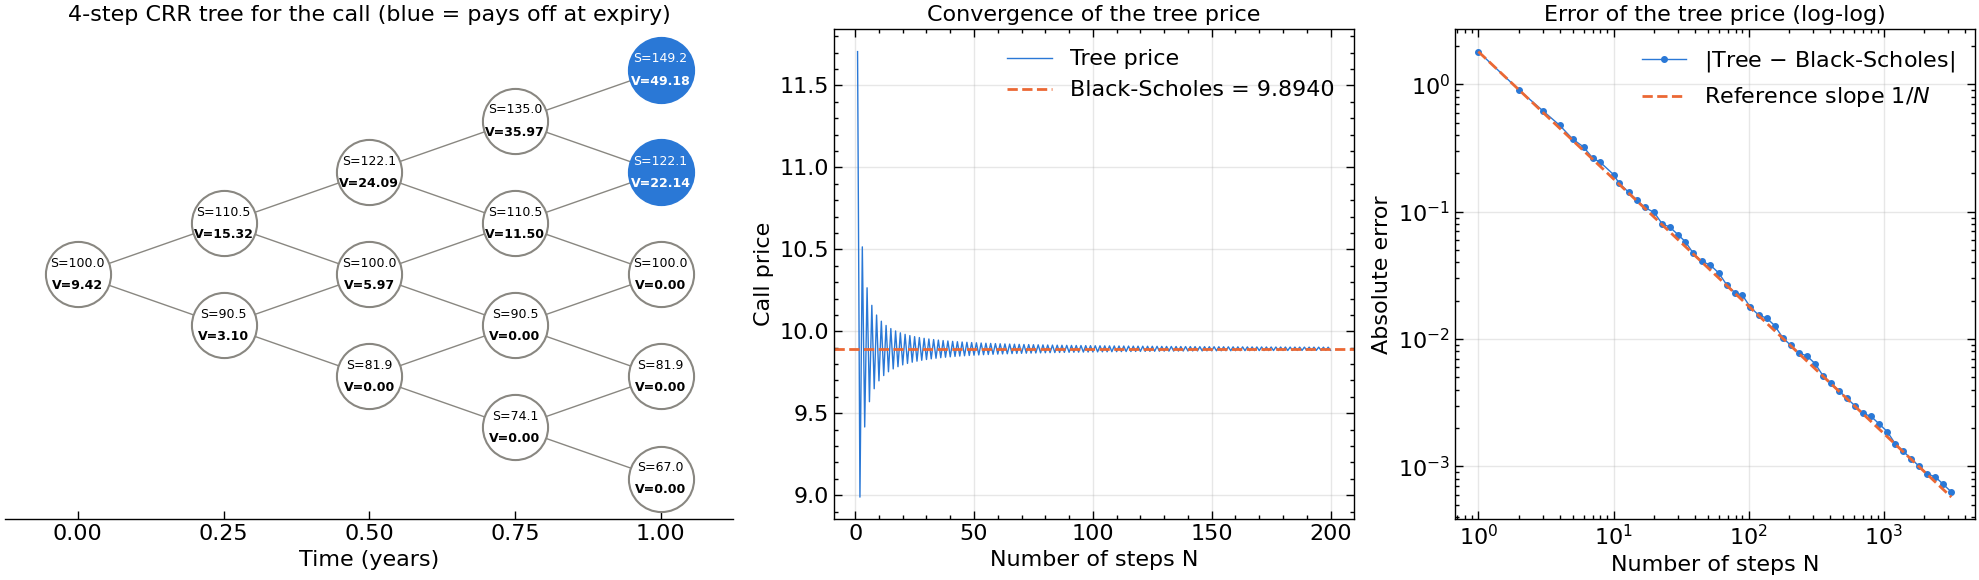

In [71]:
# Visualising the tree

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#898781"

fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.4, 1, 1]})


# Plot 1: a small tree, so every node can be read
N_small = 4
_, stock_tree, option_tree = BinomialTree(S_0, K, sigma, rf, T, N_small, option_type="C", return_tree=True)

ax = axes[0]
for i in range(N_small + 1):
    for j in range(i + 1):                  # j = number of up moves at step i
        x, y = i, 2 * j - i
        if i < N_small:                     # edges to the two children
            ax.plot([x, x + 1], [y, y + 1], color=GRAY, lw=1, zorder=1)   # up
            ax.plot([x, x + 1], [y, y - 1], color=GRAY, lw=1, zorder=1)   # down
        # final nodes where the call pays off in blue, all others in gray
        in_money = (i == N_small) and (stock_tree[i][j] > K)
        ax.scatter(x, y, s=2200, color=BLUE if in_money else "white",
                   edgecolor=BLUE if in_money else GRAY, lw=1.5, zorder=2)
        ax.text(x, y + 0.22, f"S={stock_tree[i][j]:.1f}", ha="center", va="center", fontsize=9,
                color="white" if in_money else "black", zorder=3)
        ax.text(x, y - 0.22, f"V={option_tree[i][j]:.2f}", ha="center", va="center", fontsize=9,
                color="white" if in_money else "black", fontweight="bold", zorder=3)

ax.set_title(f"{N_small}-step CRR tree for the call (blue = pays off at expiry)")
ax.set_xticks(range(N_small + 1))
ax.set_xticklabels([f"{i * T / N_small:.2f}" for i in range(N_small + 1)])
ax.set_xlabel("Time (years)")
ax.set_yticks([])
ax.tick_params(top=False, which="both")
ax.minorticks_off()
ax.set_xlim(-0.5, N_small + 0.5)
ax.set_ylim(-N_small - 0.8, N_small + 0.8)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)


# Plot 2: convergence of the tree price as N grows
N_values = np.arange(1, 201)
tree_prices = np.array([BinomialTree(S_0, K, sigma, rf, T, n, option_type="C") for n in N_values])

axes[1].plot(N_values, tree_prices, color=BLUE, lw=1, label="Tree price")
axes[1].axhline(Call, color=ORANGE, lw=2, ls="--", label=f"Black-Scholes = {Call:.4f}")
axes[1].set_title("Convergence of the tree price")
axes[1].set_xlabel("Number of steps N")
axes[1].set_ylabel("Call price")
axes[1].legend()


# Plot 3: absolute error on log-log axes
# A straight line with slope -1 means error ~ 1/N: 10x more steps -> 10x smaller
# error. Compare to Monte-Carlo, where 10x more paths only gives ~3x smaller error.
N_log = np.unique(np.logspace(0, 3.5, 60).astype(int))
errors = np.abs([BinomialTree(S_0, K, sigma, rf, T, n, option_type="C") - Call for n in N_log])

axes[2].loglog(N_log, errors, color=BLUE, marker="o", ms=4, lw=1, label="$|$Tree $-$ Black-Scholes$|$")
axes[2].loglog(N_log, errors[0] / N_log, color=ORANGE, lw=2, ls="--", label="Reference slope $1/N$")
axes[2].set_title("Error of the tree price (log-log)")
axes[2].set_xlabel("Number of steps N")
axes[2].set_ylabel("Absolute error")
axes[2].legend()

for ax in axes[1:]:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Finite Difference Grid (Crank-Nicolson)

Instead of simulating or building a tree, we solve the Black-Scholes PDE directly on a grid:

$$
\frac{\partial V}{\partial t} + \frac{1}{2}\sigma^2 S^2 \frac{\partial^2 V}{\partial S^2} + r S \frac{\partial V}{\partial S} - r V = 0
$$

**Grid** with $N_S$ price steps and $N_t$ time steps:

$$
S_i = i\,\Delta S, \quad \Delta S = \frac{S_{max}}{N_S}, \quad i = 0, \dots, N_S \qquad\qquad t_n = n\,\Delta t, \quad \Delta t = \frac{T}{N_t}, \quad n = 0, \dots, N_t
$$

We write $V_i^n = V(S_i, t_n)$ and choose $S_{max} = 4K$, far enough away that the option behaves like its boundary value.

**Terminal condition** (payoff at expiry, $n = N_t$):

$$
V_i^{N_t} = \max\left(S_i - K,\ 0\right) \quad \text{(call)}, \qquad V_i^{N_t} = \max\left(K - S_i,\ 0\right) \quad \text{(put)}
$$

**Boundary conditions** ($\tau = T - t_n$ is the time to expiry):

| | $S = 0$ | $S = S_{max}$ |
|---|---|---|
| Call | $V_0^n = 0$ | $V_{N_S}^n = S_{max} - K e^{-r\tau}$ |
| Put | $V_0^n = K e^{-r\tau}$ | $V_{N_S}^n = 0$ |

**Crank-Nicolson scheme.** The derivatives are replaced by central differences and averaged between time steps $n$ and $n+1$:

$$
\frac{\partial V}{\partial S} \approx \frac{V_{i+1} - V_{i-1}}{2\Delta S}, \qquad \frac{\partial^2 V}{\partial S^2} \approx \frac{V_{i+1} - 2V_i + V_{i-1}}{\Delta S^2}
$$

With the coefficients

$$
a_i = \frac{\Delta t}{4}\left(\sigma^2 i^2 - r i\right), \qquad b_i = -\frac{\Delta t}{2}\left(\sigma^2 i^2 + r\right), \qquad c_i = \frac{\Delta t}{4}\left(\sigma^2 i^2 + r i\right)
$$

this gives, for every interior node $i = 1, \dots, N_S - 1$:

$$
-a_i V_{i-1}^{n} + (1 - b_i) V_i^{n} - c_i V_{i+1}^{n} = a_i V_{i-1}^{n+1} + (1 + b_i) V_i^{n+1} + c_i V_{i+1}^{n+1}
$$

The right side is known (it comes from the later time step), so each step backwards in time means solving a **tridiagonal linear system** for the unknown values $V^n$. Starting at expiry, we step back from $n = N_t - 1$ to $n = 0$.

**Option price:** read off the grid at $t = 0$ at $S = S_0$ (interpolating if $S_0$ is not a grid point):

$$
C = V(S_0, 0)
$$

The error shrinks like $O(\Delta S^2 + \Delta t^2)$: the scheme is second-order accurate in both price and time.

In [76]:
def FiniteDifference(S_0, K, sigma, rf, T, N_S, N_t, option_type="C", S_max=None, return_grid=False):
    """
    Prices a European option by solving the Black-Scholes PDE with the
    Crank-Nicolson finite difference scheme.
    N_S = number of price steps, N_t = number of time steps.
    Returns the price (and, if return_grid=True, the price axis S, the time axis t
    and the full grid V[n, i] = option value at time t_n and price S_i).
    """

    # Step 1: build the grid
    if S_max is None:
        S_max = 4 * K
    dS = S_max / N_S
    dt = T / N_t
    S = np.linspace(0, S_max, N_S + 1)
    t = np.linspace(0, T, N_t + 1)

    # Step 2: terminal condition - at expiry the option is worth its payoff
    if option_type == "C":
        V = np.maximum(S - K, 0)
    elif option_type == "P":
        V = np.maximum(K - S, 0)
    else:
        raise ValueError("Option must be of type Call (C) or Put (P)")

    # Step 3: boundary conditions at S = 0 and S = S_max, as functions of time to expiry tau
    def boundaries(tau):
        if option_type == "C":
            return 0.0, S_max - K * np.exp(-rf * tau)   # call: worthless at 0, ~ forward deep ITM
        return K * np.exp(-rf * tau), 0.0               # put: ~ discounted strike at 0, worthless at S_max

    # Step 4: Crank-Nicolson coefficients for the interior nodes i = 1 ... N_S-1
    # They come from replacing dV/dS and d2V/dS2 by central differences (with S = i * dS)
    # and averaging the PDE between time step n and n+1.
    i = np.arange(1, N_S)
    a = 0.25 * dt * (sigma**2 * i**2 - rf * i)
    b = -0.5 * dt * (sigma**2 * i**2 + rf)
    c = 0.25 * dt * (sigma**2 * i**2 + rf * i)

    # Left-hand side matrix (I - A) is tridiagonal: -a below, 1-b on, -c above the diagonal.
    # solve_banded wants it in "banded" form: row 0 = upper diagonal, row 1 = diagonal,
    # row 2 = lower diagonal. Solving a tridiagonal system is O(N_S) instead of O(N_S^3).
    banded = np.zeros((3, N_S - 1))
    banded[0, 1:] = -c[:-1]
    banded[1, :] = 1 - b
    banded[2, :-1] = -a[1:]

    # Step 5: step backwards in time, from expiry (n = N_t) to today (n = 0)
    grid = [V.copy()]
    for n in range(N_t - 1, -1, -1):
        lo_new, hi_new = boundaries(T - t[n])       # boundary values at the new time step

        # Right-hand side (I + A) V^{n+1}: everything we already know.
        # V still holds time step n+1, including its boundary values V[0] and V[-1].
        rhs = a * V[:-2] + (1 + b) * V[1:-1] + c * V[2:]
        # the first and last interior node also touch the boundary at the NEW time step;
        # those values are known, so they move from the left side to the right side
        rhs[0] += a[0] * lo_new
        rhs[-1] += c[-1] * hi_new

        # Solve (I - A) V^n = rhs for the interior, then set the boundaries
        V[1:-1] = solve_banded((1, 1), banded, rhs)
        V[0], V[-1] = lo_new, hi_new

        if return_grid:
            grid.append(V.copy())

    # Step 6: read the price off the grid at S_0 (linear interpolation between nodes)
    price = np.interp(S_0, S, V)

    if return_grid:
        # reverse so that grid[n] = time step n (0 = today, N_t = expiry)
        return price, S, t, np.array(grid[::-1])
    return price

In [73]:
# Run the finite difference grid with the given data
N_S, N_t = 400, 400   # S_max = 4K = 400 -> dS = 1, so S_0 = 100 lies exactly on a grid node
fd_call = FiniteDifference(S_0, K, sigma, rf, T, N_S, N_t, option_type="C")
fd_put = FiniteDifference(S_0, K, sigma, rf, T, N_S, N_t, option_type="P")

print(f"FD-Call ({N_S}x{N_t} grid): {fd_call}; Black-Scholes: {Call}; difference: {fd_call - Call}")
print(f"FD-Put  ({N_S}x{N_t} grid): {fd_put}; Black-Scholes: {Put}; difference: {fd_put - Put}")

FD-Call (400x400 grid): 9.891504044577522; Black-Scholes: 9.893959068455047; difference: -0.0024550238775251643
FD-Put  (400x400 grid): 6.028112620765626; Black-Scholes: 6.030567647705773; difference: -0.00245502694014732


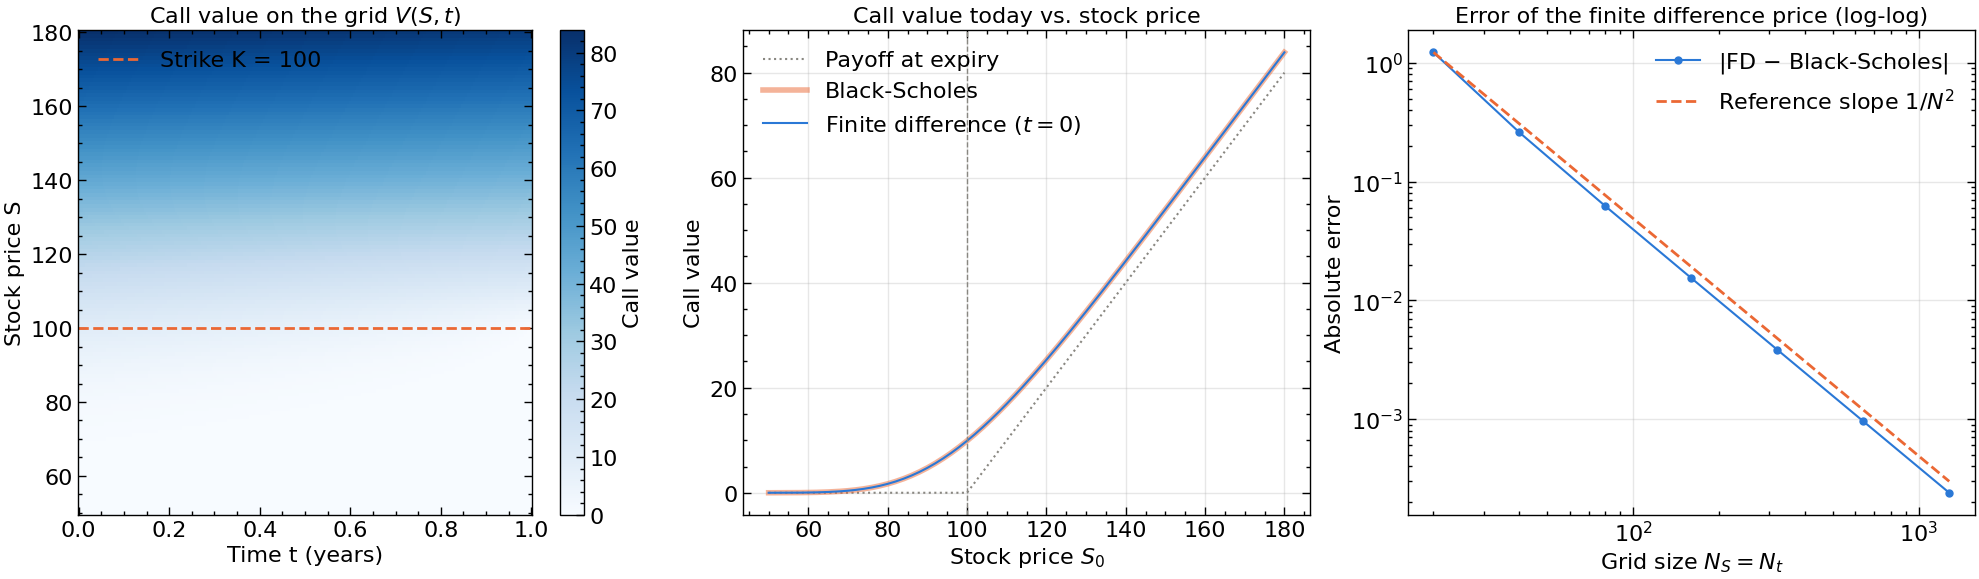

In [74]:
# Visualising the finite difference grid

BLUE, ORANGE, GRAY = "#2a78d6", "#eb6834", "#898781"

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# full grid for the plots (small enough to keep in memory)
_, S_grid, t_grid, V_grid = FiniteDifference(S_0, K, sigma, rf, T, 400, 400, option_type="C", return_grid=True)
view = (S_grid >= 50) & (S_grid <= 180)   # zoom in around the strike


# Plot 1: the whole solution V(S, t) as a heatmap
# Each column of the grid is one time step; we solved it from right (expiry) to left (today).
mesh = axes[0].pcolormesh(t_grid, S_grid[view], V_grid[:, view].T, cmap="Blues", shading="auto")
fig.colorbar(mesh, ax=axes[0], label="Call value")
axes[0].axhline(K, color=ORANGE, lw=2, ls="--", label=f"Strike K = {K}")
axes[0].set_title("Call value on the grid $V(S, t)$")
axes[0].set_xlabel("Time t (years)")
axes[0].set_ylabel("Stock price S")
axes[0].legend(loc="upper left")


# Plot 2: value today across stock prices, compared to Black-Scholes and the payoff
# The grid gives the price for EVERY S_0 at once, not just S_0 = 100.
S_view = S_grid[view]
axes[1].plot(S_view, np.maximum(S_view - K, 0), color=GRAY, lw=1.5, ls=":", label="Payoff at expiry")
axes[1].plot(S_view, BlackScholes(S_view, K, sigma, rf, T), color=ORANGE, lw=4, alpha=0.5, label="Black-Scholes")
axes[1].plot(S_view, V_grid[0, view], color=BLUE, lw=1.5, label="Finite difference ($t = 0$)")
axes[1].axvline(S_0, color=GRAY, lw=1, ls="--")
axes[1].set_title("Call value today vs. stock price")
axes[1].set_xlabel("Stock price $S_0$")
axes[1].set_ylabel("Call value")
axes[1].legend()


# Plot 3: convergence on log-log axes
# Refine price and time steps together. Crank-Nicolson is second order:
# error ~ 1/N^2, i.e. slope -2 -> doubling the grid makes the error 4x smaller.
N_fd = np.array([20, 40, 80, 160, 320, 640, 1280])
fd_errors = np.abs([FiniteDifference(S_0, K, sigma, rf, T, n, n, option_type="C") - Call for n in N_fd])

axes[2].loglog(N_fd, fd_errors, color=BLUE, marker="o", ms=5, lw=1.5, label="$|$FD $-$ Black-Scholes$|$")
axes[2].loglog(N_fd, fd_errors[0] * (N_fd[0] / N_fd)**2, color=ORANGE, lw=2, ls="--",
               label="Reference slope $1/N^2$")
axes[2].set_title("Error of the finite difference price (log-log)")
axes[2].set_xlabel("Grid size $N_S = N_t$")
axes[2].set_ylabel("Absolute error")
axes[2].legend()

for ax in axes[1:]:
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()